# Options Strategy Recommendation and Optimisation System
## Notebook 5 - Genetic Algorithm Strategy Optimisation

This notebook optimises Notebook 4's feasible option strategies with a transparent genetic algorithm (GA). It balances net expectancy, probability of profit, downside risk, capital required, liquidity, and the reasoning score from the knowledge-based layer.

The result is an explainable ranked recommendation, not trading advice.

## Scope and modelling assumptions

- Each chromosome is `[strategy_index, expiry_index, long_strike_index, short_strike_index]`; the first integer encodes the strategy type.
- Notebook 4 already enforces valid expiries, option types, strike order, debit/credit structure, and bounded maximum loss.
- The optimiser uses conservative ask prices for purchases and bid prices for sales inherited from Notebook 4.
- Explicit costs are estimated from configurable per-leg commissions/fees and slippage on gross premium. They reduce expected profit and increase capital at risk.
- Probability of profit is inherited from Notebook 4's Monte Carlo simulation; it includes bid/ask entry pricing but not the additional explicit cost estimate.
- For this MVP, exhaustive ranking is computationally possible and is used as an oracle to validate the GA. The GA becomes more useful as position size, multiple expiries, portfolio constraints, and larger strategy spaces are added.
- Outputs are decision support only. Real trading also involves fills, early assignment, volatility changes, taxes, and event risk.

## 1. Environment setup

If required, install packages once with: `pip install pandas numpy matplotlib`. No specialist GA package is required because the evolutionary operators are implemented explicitly.

In [5]:
from __future__ import annotations

import json
import math
import re
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | numpy: {np.__version__}")

Python: 3.9.23 | pandas: 2.3.2 | numpy: 1.26.4


## 2. Configuration and upstream inputs

Use the same ticker and bullish/bearish outlook as Notebooks 1-4. The only user-level inputs remain the ticker and outlook; optimisation settings below are transparent system parameters.

In [7]:
TICKER = "CRM"
OUTLOOK = "bullish"  # allowed: bullish, bearish


In [8]:
NOTEBOOK4_ROOT = Path("outputs/notebook_04")
NOTEBOOK5_ROOT = Path("outputs/notebook_05")

# Reproducible GA settings
POPULATION_SIZE = 80
GENERATIONS = 60
TOURNAMENT_SIZE = 3
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.18
ELITE_FRACTION = 0.10
RANDOM_IMMIGRANT_FRACTION = 0.05
PRIMARY_SEED = 42
EXPERIMENT_SEEDS = list(range(10))
TOP_RECOMMENDATIONS = 20

# Estimated explicit round-trip trading costs per strategy
COMMISSION_PER_CONTRACT_PER_SIDE = 0.65
REGULATORY_FEE_PER_CONTRACT_PER_SIDE = 0.03
SLIPPAGE_RATE_ON_GROSS_PREMIUM = 0.01

# Balanced decision policy. Weights must sum to 1.0.
FITNESS_WEIGHTS = {
    "net_expectancy": 0.30,
    "probability_of_profit": 0.20,
    "downside_protection": 0.15,
    "capital_efficiency": 0.10,
    "liquidity": 0.15,
    "reasoning_alignment": 0.10,
}

def validate_settings(ticker: str, outlook: str) -> tuple[str, str]:
    ticker = ticker.strip().upper().replace(".", "-")
    outlook = outlook.strip().lower()
    if not ticker or not re.fullmatch(r"[A-Z0-9.^=-]{1,15}", ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    if outlook not in {"bullish", "bearish"}:
        raise ValueError("OUTLOOK must be either 'bullish' or 'bearish'.")
    if not math.isclose(sum(FITNESS_WEIGHTS.values()), 1.0, abs_tol=1e-9):
        raise ValueError("FITNESS_WEIGHTS must sum to 1.0.")
    return ticker, outlook

ticker, outlook = validate_settings(TICKER, OUTLOOK)
run_name = f"{ticker}_{outlook}"
NOTEBOOK4_DIR = NOTEBOOK4_ROOT / ticker / outlook
OUTPUT_DIR = NOTEBOOK5_ROOT / ticker / outlook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
input_paths = {
    "candidate_universe": NOTEBOOK4_DIR / "candidate_universe.csv",
    "engine_snapshot": NOTEBOOK4_DIR / "payoff_engine_snapshot.json",
}
input_paths

{'candidate_universe': WindowsPath('outputs/notebook_04/CRM/bullish/candidate_universe.csv'),
 'engine_snapshot': WindowsPath('outputs/notebook_04/CRM/bullish/payoff_engine_snapshot.json')}

In [9]:
missing_files = [str(path) for path in input_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required Notebook 4 outputs were not found. Run Notebooks 1-4 with the same ticker/outlook first. Missing: "
        + ", ".join(missing_files)
    )

candidate_source = pd.read_csv(input_paths["candidate_universe"])
with input_paths["engine_snapshot"].open("r", encoding="utf-8") as file:
    engine_snapshot = json.load(file)

if engine_snapshot.get("request") != {"ticker": ticker, "outlook": outlook}:
    raise ValueError("Notebook 4 snapshot does not match the configured ticker/outlook.")
if candidate_source.empty:
    raise ValueError("Notebook 4 candidate universe is empty.")

required_columns = {
    "candidate_id", "strategy_type", "strategy_name", "strategy_rank", "reasoning_score",
    "strategy_index", "expiry_index", "long_strike_index", "short_strike_index",
    "expiry", "dte", "long_strike", "short_strike", "long_entry_price", "short_entry_price",
    "max_loss", "reward_to_risk", "liquidity_score", "probability_of_profit",
    "expected_profit", "expected_return_on_risk", "median_profit", "p05_profit", "p95_profit",
    "payoff_engine_rank",
}
missing_columns = sorted(required_columns - set(candidate_source.columns))
if missing_columns:
    raise KeyError(f"Notebook 4 candidate universe is missing columns: {missing_columns}")

numeric_columns = sorted(required_columns - {"candidate_id", "strategy_type", "strategy_name", "expiry"})
for column in numeric_columns:
    candidate_source[column] = pd.to_numeric(candidate_source[column], errors="coerce")
candidate_source = candidate_source.drop_duplicates("candidate_id").reset_index(drop=True)
candidate_source["source_row"] = np.arange(len(candidate_source), dtype=int)

print(f"Loaded {len(candidate_source):,} feasible candidates across {candidate_source['strategy_type'].nunique()} strategy families.")
display(candidate_source.groupby("strategy_name", as_index=False).agg(
    candidates=("candidate_id", "count"),
    median_probability_of_profit=("probability_of_profit", "median"),
    median_expected_profit=("expected_profit", "median"),
))

Loaded 64 feasible candidates across 3 strategy families.


,strategy_name,candidates,median_probability_of_profit,median_expected_profit
0,Bull Call Spread,21,0.0000,-320.0000
1,Bull Put Spread,36,1.0000,370.0000
2,Long Call,7,0.0000,-540.0000


## 3. Cost-adjusted, multi-objective fitness

Raw financial quantities have different units and ranges. Each component is winsorised at the 5th and 95th percentiles, min-max scaled to 0-1, and combined with the stated weights. Higher fitness is better.

| Component | Direction | Purpose |
|---|---:|---|
| Net expectancy | Higher | Expected return on adjusted capital after estimated costs |
| Probability of profit | Higher | Frequency of profitable Monte Carlo outcomes |
| Downside protection | Higher | Smaller cost-adjusted 5th-percentile loss relative to capital |
| Capital efficiency | Higher | Less maximum capital required |
| Liquidity | Higher | Easier execution and lower market-impact risk |
| Reasoning alignment | Higher | Preserves the knowledge-graph/rule-engine recommendation |

In [11]:
def robust_unit_scale(values: pd.Series, higher_is_better: bool = True) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce").replace([np.inf, -np.inf], np.nan)
    fill_value = float(numeric.median()) if numeric.notna().any() else 0.0
    numeric = numeric.fillna(fill_value)
    lower, upper = numeric.quantile([0.05, 0.95])
    if not np.isfinite(lower) or not np.isfinite(upper) or math.isclose(float(lower), float(upper)):
        scaled = pd.Series(0.5, index=numeric.index, dtype=float)
    else:
        scaled = (numeric.clip(lower, upper) - lower) / (upper - lower)
    return scaled if higher_is_better else 1.0 - scaled

def add_cost_adjustments(frame: pd.DataFrame, cost_multiplier: float = 1.0) -> pd.DataFrame:
    scored = frame.copy()
    scored["leg_count"] = np.where(scored["short_strike_index"].lt(0), 1, 2)
    scored["gross_premium_per_share"] = scored["long_entry_price"].abs() + scored["short_entry_price"].fillna(0).abs()
    fixed_cost = scored["leg_count"] * 2 * (
        COMMISSION_PER_CONTRACT_PER_SIDE + REGULATORY_FEE_PER_CONTRACT_PER_SIDE
    )
    slippage_cost = scored["gross_premium_per_share"] * 100 * SLIPPAGE_RATE_ON_GROSS_PREMIUM
    scored["estimated_transaction_cost"] = cost_multiplier * (fixed_cost + slippage_cost)
    scored["adjusted_expected_profit"] = scored["expected_profit"] - scored["estimated_transaction_cost"]
    scored["adjusted_max_loss"] = scored["max_loss"] + scored["estimated_transaction_cost"]
    scored["net_expected_return_on_risk"] = scored["adjusted_expected_profit"] / scored["adjusted_max_loss"].clip(lower=1e-9)
    scored["adjusted_p05_profit"] = scored["p05_profit"] - scored["estimated_transaction_cost"]
    scored["downside_loss_ratio"] = (-scored["adjusted_p05_profit"].clip(upper=0)) / scored["adjusted_max_loss"].clip(lower=1e-9)
    return scored

def build_scored_table(frame: pd.DataFrame, cost_multiplier: float = 1.0) -> pd.DataFrame:
    scored = add_cost_adjustments(frame, cost_multiplier=cost_multiplier)
    scored["component_net_expectancy"] = robust_unit_scale(scored["net_expected_return_on_risk"], True)
    scored["component_probability_of_profit"] = robust_unit_scale(scored["probability_of_profit"], True)
    scored["component_downside_protection"] = robust_unit_scale(scored["downside_loss_ratio"], False)
    scored["component_capital_efficiency"] = robust_unit_scale(scored["adjusted_max_loss"], False)
    scored["component_liquidity"] = robust_unit_scale(scored["liquidity_score"], True)
    scored["component_reasoning_alignment"] = robust_unit_scale(scored["reasoning_score"], True)
    scored["fitness_score"] = 100 * sum(
        FITNESS_WEIGHTS[name] * scored[f"component_{name}"] for name in FITNESS_WEIGHTS
    )
    scored["fitness_rank"] = scored["fitness_score"].rank(method="first", ascending=False).astype(int)
    return scored.sort_values(["fitness_rank", "strategy_rank", "payoff_engine_rank"]).reset_index(drop=True)

candidate_table = build_scored_table(candidate_source)
display(candidate_table[[
    "candidate_id", "strategy_name", "estimated_transaction_cost", "adjusted_expected_profit",
    "net_expected_return_on_risk", "probability_of_profit", "downside_loss_ratio",
    "adjusted_max_loss", "liquidity_score", "reasoning_score", "fitness_score",
]].head(10))

,candidate_id,strategy_name,estimated_transaction_cost,adjusted_expected_profit,net_expected_return_on_risk,probability_of_profit,downside_loss_ratio,adjusted_max_loss,liquidity_score,reasoning_score,fitness_score
0,bull_put_spread|2026-10-02|L6|S7,Bull Put Spread,17.0200,362.9800,0.5698,1.0000,-0.0000,637.0200,56.8421,65.0000,86.8887
1,bull_put_spread|2026-10-02|L5|S7,Bull Put Spread,14.6200,605.3800,0.4341,1.0000,-0.0000,"1,394.6200",56.5789,65.0000,83.8725
2,bull_put_spread|2026-10-02|L5|S6,Bull Put Spread,10.8200,229.1800,0.2973,1.0000,-0.0000,770.8200,56.5789,65.0000,82.6458
3,bull_put_spread|2026-10-02|L4|S6,Bull Put Spread,9.6200,350.3800,0.2124,1.0000,-0.0000,"1,649.6200",60.2632,65.0000,80.9232
4,bull_put_spread|2026-10-02|L4|S7,Bull Put Spread,13.4200,726.5800,0.3196,1.0000,-0.0000,"2,273.4200",56.8421,65.0000,79.5910
5,bull_put_spread|2026-10-02|L4|S5,Bull Put Spread,7.2200,112.7800,0.1271,1.0000,-0.0000,887.2200,56.5789,65.0000,78.9057
6,bull_put_spread|2026-10-02|L7|S8,Bull Put Spread,22.9800,193.0200,0.6288,1.0000,-0.0000,306.9800,44.0789,65.0000,77.0978
7,bull_put_spread|2026-10-02|L6|S8,Bull Put Spread,19.1800,576.8200,0.6248,1.0000,-0.0000,923.1800,44.0789,65.0000,75.5701
8,bull_put_spread|2026-10-02|L5|S8,Bull Put Spread,16.7800,819.2200,0.4874,1.0000,-0.0000,"1,680.7800",44.0789,65.0000,73.6918
9,bull_put_spread|2026-10-02|L3|S4,Bull Put Spread,5.7200,24.2800,0.0510,1.0000,-0.0000,475.7200,50.2632,65.0000,73.1333


## 4. Chromosome representation, constraint repair, and GA operators

Uniform crossover and gene-level mutation can create a chromosome that does not correspond to a valid strategy. The repair operator maps it to the nearest valid chromosome, prioritising the same strategy and expiry before strike proximity. Therefore every evaluated individual remains tradeable according to Notebook 4's structural rules.

In [13]:
GENE_COLUMNS = ["strategy_index", "expiry_index", "long_strike_index", "short_strike_index"]
feasible_chromosomes = candidate_table[GENE_COLUMNS].astype(int).to_numpy()
fitness_by_chromosome = {
    tuple(map(int, chromosome)): float(fitness)
    for chromosome, fitness in zip(feasible_chromosomes, candidate_table["fitness_score"])
}
row_by_chromosome = {
    tuple(map(int, chromosome)): int(index)
    for index, chromosome in enumerate(feasible_chromosomes)
}

def chromosome_tuple(chromosome: np.ndarray | list[int] | tuple[int, ...]) -> tuple[int, int, int, int]:
    return tuple(int(value) for value in chromosome)

def repair_chromosome(chromosome: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    key = chromosome_tuple(chromosome)
    if key in fitness_by_chromosome:
        return np.asarray(key, dtype=int)

    target = np.asarray(chromosome, dtype=int)
    strategy_penalty = (feasible_chromosomes[:, 0] != target[0]).astype(float) * 8.0
    expiry_penalty = (feasible_chromosomes[:, 1] != target[1]).astype(float) * 4.0
    long_scale = max(1, int(np.ptp(feasible_chromosomes[:, 2])))
    short_scale = max(1, int(np.ptp(feasible_chromosomes[:, 3])))
    strike_distance = (
        np.abs(feasible_chromosomes[:, 2] - target[2]) / long_scale
        + np.abs(feasible_chromosomes[:, 3] - target[3]) / short_scale
    )
    distances = strategy_penalty + expiry_penalty + strike_distance
    nearest = np.flatnonzero(np.isclose(distances, distances.min()))
    return feasible_chromosomes[int(rng.choice(nearest))].copy()

def tournament_select(population: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    contestant_indices = rng.integers(0, len(population), size=TOURNAMENT_SIZE)
    contestants = population[contestant_indices]
    scores = np.array([fitness_by_chromosome[chromosome_tuple(item)] for item in contestants])
    return contestants[int(np.argmax(scores))].copy()

def crossover(parent_a: np.ndarray, parent_b: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    if rng.random() >= CROSSOVER_RATE:
        return parent_a.copy(), parent_b.copy()
    mask = rng.random(len(GENE_COLUMNS)) < 0.5
    child_a = np.where(mask, parent_a, parent_b)
    child_b = np.where(mask, parent_b, parent_a)
    return repair_chromosome(child_a, rng), repair_chromosome(child_b, rng)

def mutate(chromosome: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    child = chromosome.copy()
    for gene_index in range(len(GENE_COLUMNS)):
        if rng.random() < MUTATION_RATE:
            donor = feasible_chromosomes[int(rng.integers(0, len(feasible_chromosomes)))]
            child[gene_index] = donor[gene_index]
    return repair_chromosome(child, rng)

print(f"Feasible chromosome catalogue: {len(feasible_chromosomes):,} unique candidates")

Feasible chromosome catalogue: 64 unique candidates


In [14]:
def run_genetic_algorithm(seed: int) -> tuple[dict[str, Any], pd.DataFrame]:
    rng = np.random.default_rng(seed)
    population_size = max(12, min(POPULATION_SIZE, max(12, len(feasible_chromosomes) * 2)))
    initial_indices = rng.integers(0, len(feasible_chromosomes), size=population_size)
    population = feasible_chromosomes[initial_indices].copy()
    elite_count = max(1, int(round(population_size * ELITE_FRACTION)))
    immigrant_count = max(1, int(round(population_size * RANDOM_IMMIGRANT_FRACTION)))
    history_rows: list[dict[str, Any]] = []

    def record(generation: int, current_population: np.ndarray) -> None:
        scores = np.array([fitness_by_chromosome[chromosome_tuple(item)] for item in current_population])
        best_position = int(np.argmax(scores))
        history_rows.append({
            "seed": seed,
            "generation": generation,
            "best_fitness": float(scores[best_position]),
            "mean_fitness": float(scores.mean()),
            "median_fitness": float(np.median(scores)),
            "population_diversity": int(len({chromosome_tuple(item) for item in current_population})),
            "best_chromosome": str(list(map(int, current_population[best_position]))),
        })

    record(0, population)
    for generation in range(1, GENERATIONS + 1):
        scores = np.array([fitness_by_chromosome[chromosome_tuple(item)] for item in population])
        elite_indices = np.argsort(scores)[-elite_count:]
        next_population = [population[index].copy() for index in elite_indices]

        target_children = population_size - immigrant_count
        while len(next_population) < target_children:
            parent_a = tournament_select(population, rng)
            parent_b = tournament_select(population, rng)
            child_a, child_b = crossover(parent_a, parent_b, rng)
            next_population.append(mutate(child_a, rng))
            if len(next_population) < target_children:
                next_population.append(mutate(child_b, rng))

        immigrant_indices = rng.integers(0, len(feasible_chromosomes), size=immigrant_count)
        next_population.extend(feasible_chromosomes[immigrant_indices].copy())
        population = np.asarray(next_population[:population_size], dtype=int)
        record(generation, population)

    final_scores = np.array([fitness_by_chromosome[chromosome_tuple(item)] for item in population])
    best_chromosome = population[int(np.argmax(final_scores))]
    best_key = chromosome_tuple(best_chromosome)
    result = {
        "seed": seed,
        "best_chromosome": best_key,
        "best_fitness": float(fitness_by_chromosome[best_key]),
        "candidate_row": int(row_by_chromosome[best_key]),
    }
    return result, pd.DataFrame(history_rows)

primary_result, convergence_history = run_genetic_algorithm(PRIMARY_SEED)
ga_best = candidate_table.iloc[primary_result["candidate_row"]].copy()
print(f"Primary GA best: {ga_best['candidate_id']} | fitness={ga_best['fitness_score']:.4f}")

Primary GA best: bull_put_spread|2026-10-02|L6|S7 | fitness=86.8887


## 5. Convergence and repeated-seed experiment

Elitism makes the best-so-far fitness non-decreasing. Repeating the GA across seeds tests whether the result is stable rather than an artefact of one random initial population.

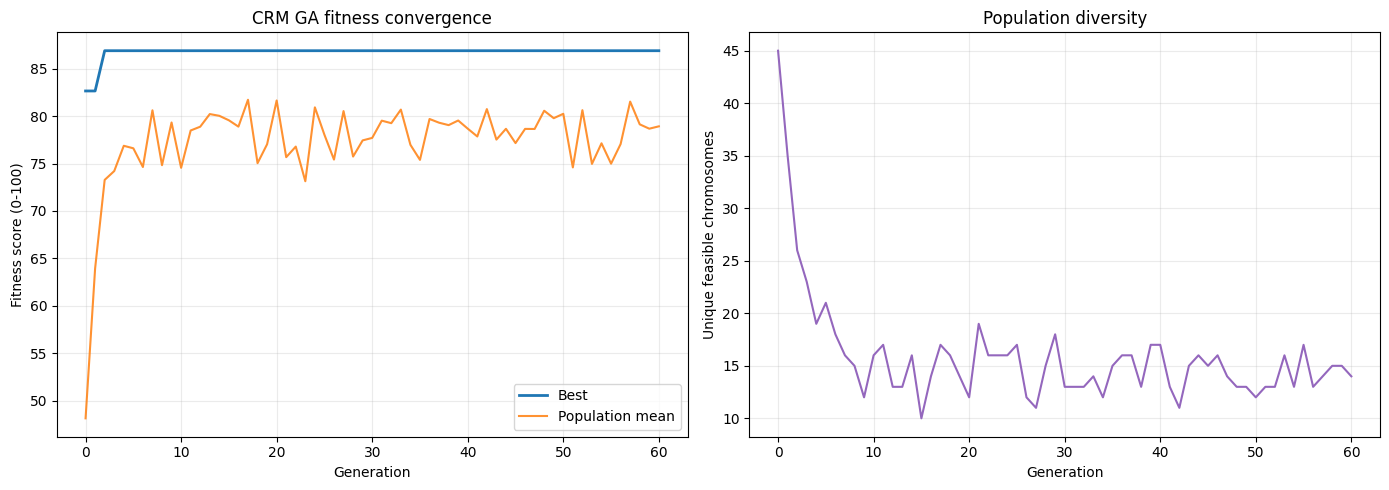

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(convergence_history["generation"], convergence_history["best_fitness"], label="Best", linewidth=2)
axes[0].plot(convergence_history["generation"], convergence_history["mean_fitness"], label="Population mean", alpha=0.85)
axes[0].set_title(f"{ticker} GA fitness convergence")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness score (0-100)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(convergence_history["generation"], convergence_history["population_diversity"], color="tab:purple")
axes[1].set_title("Population diversity")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Unique feasible chromosomes")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
experiment_results: list[dict[str, Any]] = []
experiment_histories: list[pd.DataFrame] = []
for seed in EXPERIMENT_SEEDS:
    result, history = run_genetic_algorithm(seed)
    selected = candidate_table.iloc[result["candidate_row"]]
    experiment_results.append({
        "seed": seed,
        "candidate_id": selected["candidate_id"],
        "strategy_type": selected["strategy_type"],
        "best_fitness": result["best_fitness"],
        "best_chromosome": str(list(result["best_chromosome"])),
    })
    experiment_histories.append(history)

ga_run_summary = pd.DataFrame(experiment_results)
all_run_history = pd.concat(experiment_histories, ignore_index=True)
oracle = candidate_table.nlargest(1, "fitness_score").iloc[0]
ga_run_summary["optimality_gap"] = float(oracle["fitness_score"]) - ga_run_summary["best_fitness"]
ga_run_summary["reached_oracle"] = ga_run_summary["optimality_gap"].abs().le(1e-9)

display(ga_run_summary)
print(
    f"Oracle hit rate: {ga_run_summary['reached_oracle'].mean():.1%} | "
    f"mean best fitness: {ga_run_summary['best_fitness'].mean():.4f} | "
    f"worst optimality gap: {ga_run_summary['optimality_gap'].max():.4f}"
)

,seed,candidate_id,strategy_type,best_fitness,best_chromosome,optimality_gap,reached_oracle
0,0,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
1,1,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
2,2,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
3,3,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
4,4,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
5,5,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
6,6,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
7,7,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
8,8,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True
9,9,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,"[2, 2, 6, 7]",0.0000,True


Oracle hit rate: 100.0% | mean best fitness: 86.8887 | worst optimality gap: 0.0000


## 6. Quantitative benchmark against baselines

The exhaustive oracle is not used inside the GA. It is calculated afterward to quantify the optimality gap. The rule/payoff baseline is the first candidate produced by Notebook 4's strategy rank and within-strategy payoff rank.

,method,candidate_id,fitness_score,gap_to_oracle,improvement_vs_rule_baseline
0,Random feasible candidate (mean),None,49.2334,37.6553,26.2573
1,Notebook 4 rule/payoff baseline,bull_call_spread|2026-10-02|L0|S1,22.9761,63.9126,0.0000
2,Genetic algorithm,bull_put_spread|2026-10-02|L6|S7,86.8887,0.0000,63.9126
3,Exhaustive oracle,bull_put_spread|2026-10-02|L6|S7,86.8887,0.0000,63.9126


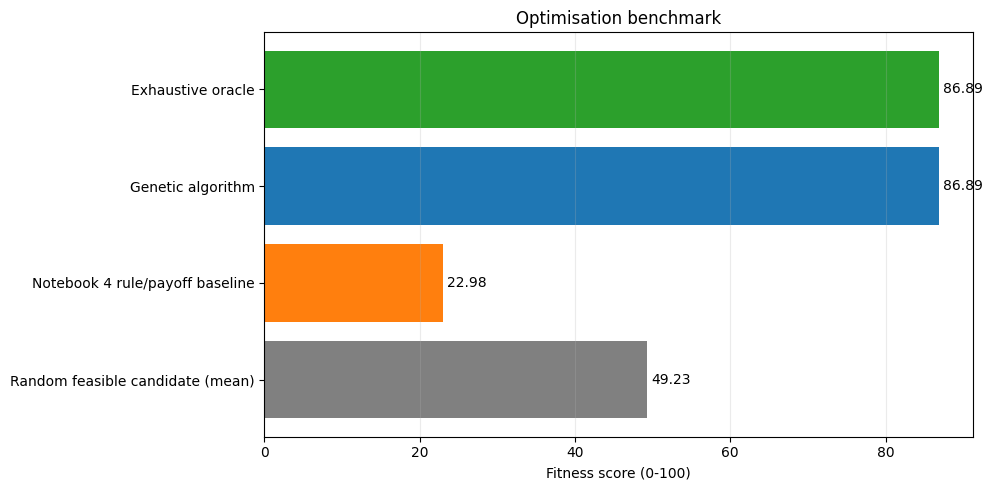

In [19]:
rule_payoff_baseline = candidate_table.sort_values(["strategy_rank", "payoff_engine_rank"]).iloc[0]
random_average_fitness = float(candidate_table["fitness_score"].mean())

benchmark_table = pd.DataFrame([
    {
        "method": "Random feasible candidate (mean)",
        "candidate_id": None,
        "fitness_score": random_average_fitness,
        "gap_to_oracle": float(oracle["fitness_score"]) - random_average_fitness,
    },
    {
        "method": "Notebook 4 rule/payoff baseline",
        "candidate_id": rule_payoff_baseline["candidate_id"],
        "fitness_score": float(rule_payoff_baseline["fitness_score"]),
        "gap_to_oracle": float(oracle["fitness_score"] - rule_payoff_baseline["fitness_score"]),
    },
    {
        "method": "Genetic algorithm",
        "candidate_id": ga_best["candidate_id"],
        "fitness_score": float(ga_best["fitness_score"]),
        "gap_to_oracle": float(oracle["fitness_score"] - ga_best["fitness_score"]),
    },
    {
        "method": "Exhaustive oracle",
        "candidate_id": oracle["candidate_id"],
        "fitness_score": float(oracle["fitness_score"]),
        "gap_to_oracle": 0.0,
    },
])
benchmark_table["improvement_vs_rule_baseline"] = benchmark_table["fitness_score"] - float(rule_payoff_baseline["fitness_score"])
display(benchmark_table)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(benchmark_table["method"], benchmark_table["fitness_score"], color=["grey", "tab:orange", "tab:blue", "tab:green"])
ax.set_title("Optimisation benchmark")
ax.set_xlabel("Fitness score (0-100)")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

## 7. Transaction-cost sensitivity

The same fitness policy is recalculated at 0x, 1x, and 2x the default cost estimate. A stable recommendation should remain competitive when execution costs increase.

In [21]:
sensitivity_rows: list[dict[str, Any]] = []
for multiplier in [0.0, 1.0, 2.0]:
    sensitivity_table = build_scored_table(candidate_source, cost_multiplier=multiplier)
    best = sensitivity_table.iloc[0]
    sensitivity_rows.append({
        "cost_multiplier": multiplier,
        "candidate_id": best["candidate_id"],
        "strategy_type": best["strategy_type"],
        "fitness_score": best["fitness_score"],
        "estimated_transaction_cost": best["estimated_transaction_cost"],
        "adjusted_expected_profit": best["adjusted_expected_profit"],
        "net_expected_return_on_risk": best["net_expected_return_on_risk"],
    })
cost_sensitivity = pd.DataFrame(sensitivity_rows)
display(cost_sensitivity)

,cost_multiplier,candidate_id,strategy_type,fitness_score,estimated_transaction_cost,adjusted_expected_profit,net_expected_return_on_risk
0,0.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.9016,0.0000,380.0000,0.6129
1,1.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8887,17.0200,362.9800,0.5698
2,2.0000,bull_put_spread|2026-10-02|L6|S7,bull_put_spread,86.8757,34.0400,345.9600,0.5290


## 8. Explainable final recommendations

The GA searches the feasible space, while the final table remains fully interpretable. The highest weighted fitness components are shown as the recommendation's main strengths.

In [23]:
component_columns = [f"component_{name}" for name in FITNESS_WEIGHTS]

def recommendation_explanation(row: pd.Series) -> str:
    contributions = {
        name: FITNESS_WEIGHTS[name] * float(row[f"component_{name}"])
        for name in FITNESS_WEIGHTS
    }
    strengths = sorted(contributions, key=contributions.get, reverse=True)[:2]
    strength_labels = {
        "net_expectancy": "cost-adjusted expectancy",
        "probability_of_profit": "probability of profit",
        "downside_protection": "downside protection",
        "capital_efficiency": "capital efficiency",
        "liquidity": "liquidity",
        "reasoning_alignment": "rule/knowledge alignment",
    }
    return (
        f"Selected for strong {strength_labels[strengths[0]]} and {strength_labels[strengths[1]]}; "
        f"estimated explicit cost ${row['estimated_transaction_cost']:.2f}, "
        f"net expected profit ${row['adjusted_expected_profit']:.2f}, "
        f"probability of profit {row['probability_of_profit']:.1%}."
    )

ranked_recommendations = candidate_table.copy()
ranked_recommendations["ga_selected_primary_run"] = ranked_recommendations["candidate_id"].eq(ga_best["candidate_id"])
ranked_recommendations["recommendation_explanation"] = ranked_recommendations.apply(recommendation_explanation, axis=1)
ranked_recommendations = ranked_recommendations.sort_values("fitness_rank").reset_index(drop=True)

display(ranked_recommendations[[
    "fitness_rank", "strategy_name", "expiry", "long_strike", "short_strike",
    "adjusted_expected_profit", "probability_of_profit", "adjusted_max_loss",
    "liquidity_score", "fitness_score", "recommendation_explanation",
]].head(TOP_RECOMMENDATIONS))

print("PRIMARY RECOMMENDATION")
print(f"Strategy: {ga_best['strategy_name']} ({ga_best['strategy_type']})")
print(f"Expiry: {ga_best['expiry']} | Long strike: {ga_best['long_strike']} | Short strike: {ga_best['short_strike']}")
print(recommendation_explanation(ga_best))

,fitness_rank,strategy_name,expiry,long_strike,short_strike,adjusted_expected_profit,probability_of_profit,adjusted_max_loss,liquidity_score,fitness_score,recommendation_explanation
0,1,Bull Put Spread,2026-10-02,190.0000,200.0000,362.9800,1.0000,637.0200,56.8421,86.8887,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $17.02, net expected profit $362.98, pro..."
1,2,Bull Put Spread,2026-10-02,180.0000,200.0000,605.3800,1.0000,"1,394.6200",56.5789,83.8725,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $14.62, net expected profit $605.38, pro..."
2,3,Bull Put Spread,2026-10-02,180.0000,190.0000,229.1800,1.0000,770.8200,56.5789,82.6458,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $10.82, net expected profit $229.18, pro..."
3,4,Bull Put Spread,2026-10-02,170.0000,190.0000,350.3800,1.0000,"1,649.6200",60.2632,80.9232,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $9.62, net expected profit $350.38, prob..."
4,5,Bull Put Spread,2026-10-02,170.0000,200.0000,726.5800,1.0000,"2,273.4200",56.8421,79.5910,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $13.42, net expected profit $726.58, pro..."
5,6,Bull Put Spread,2026-10-02,170.0000,180.0000,112.7800,1.0000,887.2200,56.5789,78.9057,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $7.22, net expected profit $112.78, prob..."
6,7,Bull Put Spread,2026-10-02,200.0000,205.0000,193.0200,1.0000,306.9800,44.0789,77.0978,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $22.98, net expected profit $193.02, pro..."
7,8,Bull Put Spread,2026-10-02,190.0000,205.0000,576.8200,1.0000,923.1800,44.0789,75.5701,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $19.18, net expected profit $576.82, pro..."
8,9,Bull Put Spread,2026-10-02,180.0000,205.0000,819.2200,1.0000,"1,680.7800",44.0789,73.6918,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $16.78, net expected profit $819.22, pro..."
9,10,Bull Put Spread,2026-10-02,165.0000,170.0000,24.2800,1.0000,475.7200,50.2632,73.1333,"Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $5.72, net expected profit $24.28, proba..."


PRIMARY RECOMMENDATION
Strategy: Bull Put Spread (bull_put_spread)
Expiry: 2026-10-02 | Long strike: 190.0 | Short strike: 200.0
Selected for strong cost-adjusted expectancy and probability of profit; estimated explicit cost $17.02, net expected profit $362.98, probability of profit 100.0%.


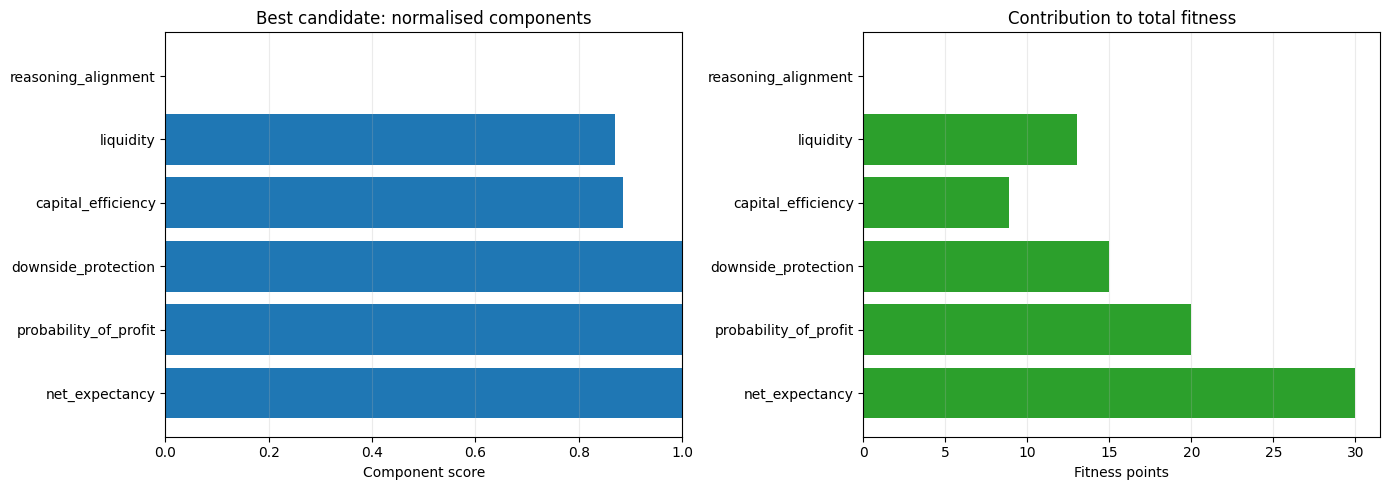

In [24]:
best_components = pd.DataFrame({
    "component": list(FITNESS_WEIGHTS),
    "normalised_score": [float(ga_best[f"component_{name}"]) for name in FITNESS_WEIGHTS],
    "weight": [FITNESS_WEIGHTS[name] for name in FITNESS_WEIGHTS],
})
best_components["weighted_contribution"] = best_components["normalised_score"] * best_components["weight"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(best_components["component"], best_components["normalised_score"], color="tab:blue")
axes[0].set_xlim(0, 1)
axes[0].set_title("Best candidate: normalised components")
axes[0].set_xlabel("Component score")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(best_components["component"], best_components["weighted_contribution"], color="tab:green")
axes[1].set_title("Contribution to total fitness")
axes[1].set_xlabel("Fitness points")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Optimisation quality checks

In [26]:
primary_optimality_gap = float(oracle["fitness_score"] - ga_best["fitness_score"])
quality_checks = {
    "candidate_universe_is_not_empty": not candidate_table.empty,
    "candidate_ids_are_unique": not candidate_table["candidate_id"].duplicated().any(),
    "chromosomes_are_unique": len(fitness_by_chromosome) == len(candidate_table),
    "fitness_weights_sum_to_one": math.isclose(sum(FITNESS_WEIGHTS.values()), 1.0, abs_tol=1e-9),
    "all_fitness_scores_are_finite": bool(np.isfinite(candidate_table["fitness_score"]).all()),
    "all_fitness_scores_are_bounded": bool(candidate_table["fitness_score"].between(0, 100).all()),
    "all_adjusted_max_losses_are_positive": bool(candidate_table["adjusted_max_loss"].gt(0).all()),
    "primary_ga_result_is_feasible": chromosome_tuple(primary_result["best_chromosome"]) in fitness_by_chromosome,
    "all_experiment_results_are_feasible": set(ga_run_summary["candidate_id"]).issubset(set(candidate_table["candidate_id"])),
    "elitist_best_fitness_is_monotonic": bool(convergence_history["best_fitness"].diff().fillna(0).ge(-1e-10).all()),
    "all_runs_completed_expected_generations": bool(all_run_history.groupby("seed")["generation"].max().eq(GENERATIONS).all()),
    "primary_ga_gap_to_oracle_is_small": primary_optimality_gap <= 1.0,
    "recommendation_matches_requested_direction": ga_best["strategy_type"] in (
        {"bull_call_spread", "bull_put_spread", "long_call"}
        if outlook == "bullish"
        else {"bear_put_spread", "bear_call_spread", "long_put"}
    ),
    "three_cost_scenarios_were_tested": len(cost_sensitivity) == 3,
}
ga_quality_report = pd.DataFrame([{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()])
display(ga_quality_report)
failed = ga_quality_report.loc[~ga_quality_report["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"GA optimisation quality checks failed: {failed}")
print("All GA optimisation quality checks passed.")

,check,passed
0,candidate_universe_is_not_empty,True
1,candidate_ids_are_unique,True
2,chromosomes_are_unique,True
3,fitness_weights_sum_to_one,True
4,all_fitness_scores_are_finite,True
5,all_fitness_scores_are_bounded,True
6,all_adjusted_max_losses_are_positive,True
7,primary_ga_result_is_feasible,True
8,all_experiment_results_are_feasible,True
9,elitist_best_fitness_is_monotonic,True


All GA optimisation quality checks passed.


## 10. Export the recommendation and experimental evidence

In [28]:
best_strategy_record = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "candidate_id": ga_best["candidate_id"],
    "chromosome": list(map(int, primary_result["best_chromosome"])),
    "strategy_type": ga_best["strategy_type"],
    "strategy_name": ga_best["strategy_name"],
    "expiry": str(ga_best["expiry"]),
    "long_symbol": ga_best.get("long_symbol"),
    "long_strike": float(ga_best["long_strike"]),
    "short_symbol": None if pd.isna(ga_best.get("short_symbol")) else ga_best.get("short_symbol"),
    "short_strike": None if pd.isna(ga_best["short_strike"]) else float(ga_best["short_strike"]),
    "fitness_score": float(ga_best["fitness_score"]),
    "estimated_transaction_cost": float(ga_best["estimated_transaction_cost"]),
    "adjusted_expected_profit": float(ga_best["adjusted_expected_profit"]),
    "probability_of_profit": float(ga_best["probability_of_profit"]),
    "adjusted_max_loss": float(ga_best["adjusted_max_loss"]),
    "net_expected_return_on_risk": float(ga_best["net_expected_return_on_risk"]),
    "optimality_gap": primary_optimality_gap,
    "explanation": recommendation_explanation(ga_best),
}

optimisation_snapshot = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "candidate_count": int(len(candidate_table)),
    "chromosome_schema": GENE_COLUMNS,
    "ga_parameters": {
        "population_size": POPULATION_SIZE,
        "generations": GENERATIONS,
        "tournament_size": TOURNAMENT_SIZE,
        "crossover_rate": CROSSOVER_RATE,
        "mutation_rate": MUTATION_RATE,
        "elite_fraction": ELITE_FRACTION,
        "random_immigrant_fraction": RANDOM_IMMIGRANT_FRACTION,
        "primary_seed": PRIMARY_SEED,
        "experiment_seeds": EXPERIMENT_SEEDS,
    },
    "fitness_weights": FITNESS_WEIGHTS,
    "transaction_cost_assumptions": {
        "commission_per_contract_per_side": COMMISSION_PER_CONTRACT_PER_SIDE,
        "regulatory_fee_per_contract_per_side": REGULATORY_FEE_PER_CONTRACT_PER_SIDE,
        "slippage_rate_on_gross_premium": SLIPPAGE_RATE_ON_GROSS_PREMIUM,
    },
    "oracle_fitness": float(oracle["fitness_score"]),
    "primary_ga_fitness": float(ga_best["fitness_score"]),
    "primary_optimality_gap": primary_optimality_gap,
    "oracle_hit_rate_across_seeds": float(ga_run_summary["reached_oracle"].mean()),
}

export_paths = {
    "ranked_recommendations": OUTPUT_DIR / "ga_ranked_recommendations.csv",
    "best_strategy": OUTPUT_DIR / "ga_best_strategy.json",
    "convergence_history": OUTPUT_DIR / "ga_convergence_history.csv",
    "run_summary": OUTPUT_DIR / "ga_run_summary.csv",
    "benchmark": OUTPUT_DIR / "ga_benchmark.csv",
    "cost_sensitivity": OUTPUT_DIR / "ga_cost_sensitivity.csv",
    "quality_report": OUTPUT_DIR / "ga_quality_report.csv",
    "optimisation_snapshot": OUTPUT_DIR / "ga_optimisation_snapshot.json",
}

ranked_recommendations.to_csv(export_paths["ranked_recommendations"], index=False)
convergence_history.to_csv(export_paths["convergence_history"], index=False)
ga_run_summary.to_csv(export_paths["run_summary"], index=False)
benchmark_table.to_csv(export_paths["benchmark"], index=False)
cost_sensitivity.to_csv(export_paths["cost_sensitivity"], index=False)
ga_quality_report.to_csv(export_paths["quality_report"], index=False)
with export_paths["best_strategy"].open("w", encoding="utf-8") as file:
    json.dump(best_strategy_record, file, indent=2, allow_nan=False)
with export_paths["optimisation_snapshot"].open("w", encoding="utf-8") as file:
    json.dump(optimisation_snapshot, file, indent=2, allow_nan=False)

export_manifest = pd.DataFrame([{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in export_paths.items()])
display(export_manifest)
success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "notebook": "05_Genetic_Algorithm_Strategy_Optimisation.ipynb",
}, indent=2), encoding="utf-8")
print(f"Completion marker: {success_marker}")


,dataset,path,exists
0,ranked_recommendations,outputs\notebook_05\CRM\bullish\ga_ranked_recommendations.csv,True
1,best_strategy,outputs\notebook_05\CRM\bullish\ga_best_strategy.json,True
2,convergence_history,outputs\notebook_05\CRM\bullish\ga_convergence_history.csv,True
3,run_summary,outputs\notebook_05\CRM\bullish\ga_run_summary.csv,True
4,benchmark,outputs\notebook_05\CRM\bullish\ga_benchmark.csv,True
5,cost_sensitivity,outputs\notebook_05\CRM\bullish\ga_cost_sensitivity.csv,True
6,quality_report,outputs\notebook_05\CRM\bullish\ga_quality_report.csv,True
7,optimisation_snapshot,outputs\notebook_05\CRM\bullish\ga_optimisation_snapshot.json,True


Completion marker: outputs\notebook_05\CRM\bullish\_SUCCESS.json


## 11. Key optimisation fields

In [30]:
optimisation_dictionary = pd.DataFrame([
    ("fitness_score", "Weighted 0-100 score across six normalised decision objectives"),
    ("estimated_transaction_cost", "Estimated round-trip commissions, fees, and slippage per strategy"),
    ("adjusted_expected_profit", "Notebook 4 expected profit less estimated explicit transaction cost"),
    ("net_expected_return_on_risk", "Adjusted expected profit divided by adjusted maximum loss"),
    ("downside_loss_ratio", "Cost-adjusted 5th-percentile loss divided by adjusted maximum loss"),
    ("chromosome", "Strategy, expiry, long-strike, and short-strike integer encoding"),
    ("population_diversity", "Number of unique feasible chromosomes in a generation"),
    ("optimality_gap", "Exhaustive oracle fitness minus GA best fitness; lower is better"),
    ("reached_oracle", "Whether a repeated GA run found the exhaustive best candidate"),
], columns=["field", "meaning"])
display(optimisation_dictionary)

,field,meaning
0,fitness_score,Weighted 0-100 score across six normalised decision objectives
1,estimated_transaction_cost,"Estimated round-trip commissions, fees, and slippage per strategy"
2,adjusted_expected_profit,Notebook 4 expected profit less estimated explicit transaction cost
3,net_expected_return_on_risk,Adjusted expected profit divided by adjusted maximum loss
4,downside_loss_ratio,Cost-adjusted 5th-percentile loss divided by adjusted maximum loss
5,chromosome,"Strategy, expiry, long-strike, and short-strike integer encoding"
6,population_diversity,Number of unique feasible chromosomes in a generation
7,optimality_gap,Exhaustive oracle fitness minus GA best fitness; lower is better
8,reached_oracle,Whether a repeated GA run found the exhaustive best candidate


## Notebook 5 completion criteria

Notebook 5 is complete when all optimisation quality checks pass and eight output files are created. The primary recommendation must be a feasible chromosome, the elitist convergence trace must be monotonic, repeated-seed results must be recorded, and the GA must be quantitatively compared with both the Notebook 4 baseline and exhaustive oracle.

The next notebook can evaluate the full end-to-end recommendation system through scenario tests, rule coverage, optimisation experiments, limitations, and final visual reporting.